https://www.youtube.com/watch?v=bX6GLbpw-A4 => LSTM 설명

| 구분 | RNN                        | LSTM                 |
| -- | -------------------------- | -------------------- |
| 기억 | 짧음 (vanishing gradient 문제) | 김 (장기 의존성 해결)        |
| 구조 | 단순 hidden state            | cell state + gate 구조 |
| 학습 | 오래된 정보 잘 잊음                | 중요한 정보 오래 유지         |
| 성능 | 기본 시퀀스                     | 대부분 실전 표준            |


https://velog.io/@lighthouse97/Gated-Recurrent-UnitGRU%EC%9D%98-%EC%9D%B4%ED%95%B4

2. 구조 차이 (핵심)
🔵 RNN 구조
xₜ → hₜ → hₜ₊₁

공식:

hₜ = tanh(Wx + Wh·hₜ₋₁)

👉 문제:

시간이 길어지면 이전 정보가 사라짐
gradient vanishing 발생



3. LSTM이 해결하는 문제
❌ RNN 문제
"나는 어제 ... 아주 긴 문장 ... 결국 오늘 결론은"
→ 초반 정보 거의 사라짐

LSTM 해결
cell state에 중요한 정보 “보존”
불필요한 정보 “삭제”

✅ 4. 핵심 구조 비교
🔴 RNN
hₜ = f(xₜ, hₜ₋₁)

👉 “하나의 기억만 계속 덮어씀”

🟢 LSTM
Cₜ = forget + input
hₜ = output gate × tanh(Cₜ)

👉 “기억을 저장하는 창고(cell state)가 따로 있음”

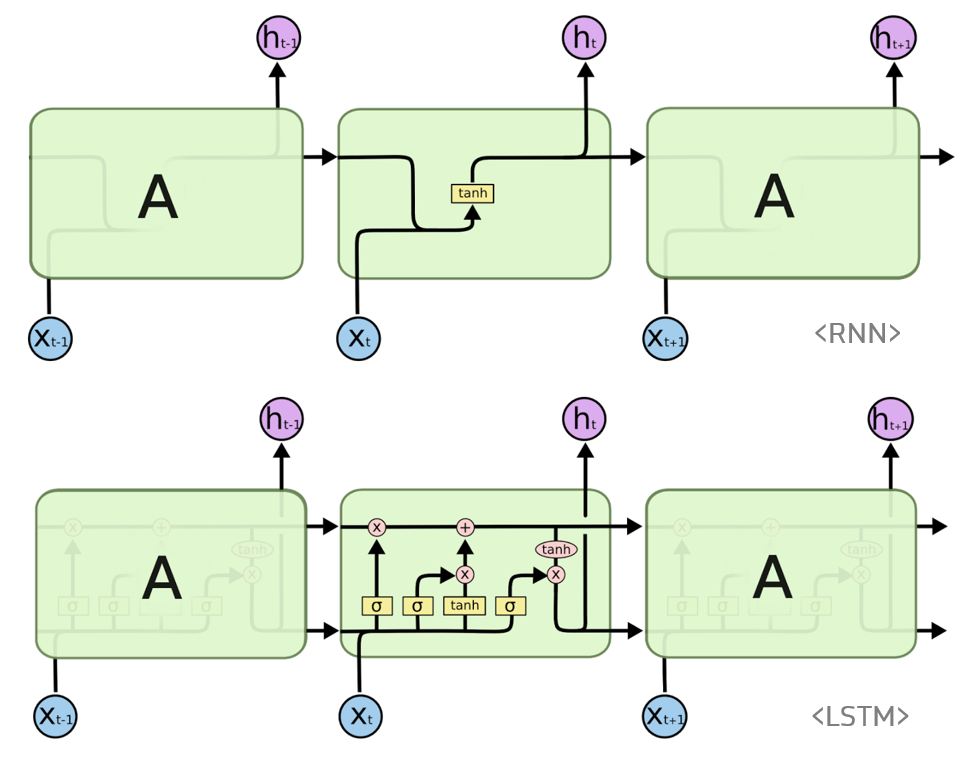

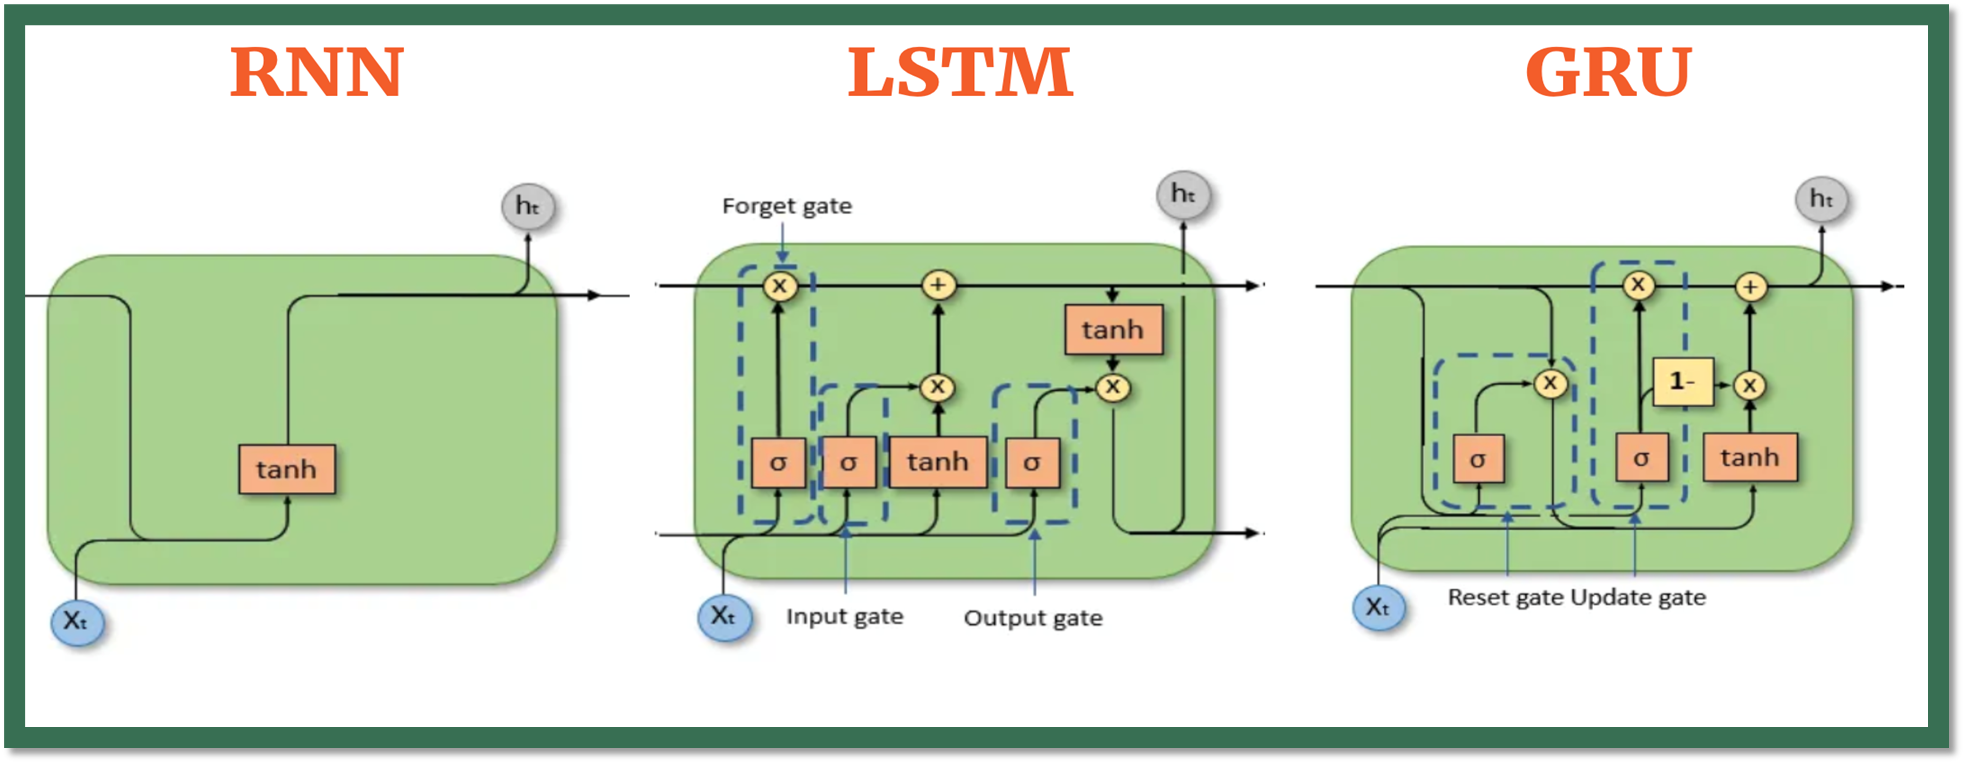

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.9755e-05 - mae: 0.0046 - val_loss: 7.8043e-05 - val_mae: 0.0067
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 4.2291e-05 - mae: 0.0048 - val_loss: 7.1923e-05 - val_mae: 0.0064
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4.0680e-05 - mae: 0.0048 - val_loss: 6.8468e-05 - val_mae: 0.0063
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.3474e-05 - mae: 0.0043 - val_loss: 6.6368e-05 - val_mae: 0.0062
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 3.3181e-05 - mae: 0.0043 - val_loss: 6.4942e-05 - val_mae: 0.0061
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.0771e-05 - mae: 0.0042 - val_loss: 8.1926e-05 - val_mae: 0.0070
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.2981e-05 - mae: 0.0044 - val_loss: 5.9126e-05 - val_mae: 0.0057
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.0876e-05 - mae: 0.0042 - val_loss: 6.2581e-05 - val_mae: 0.0062
Ep

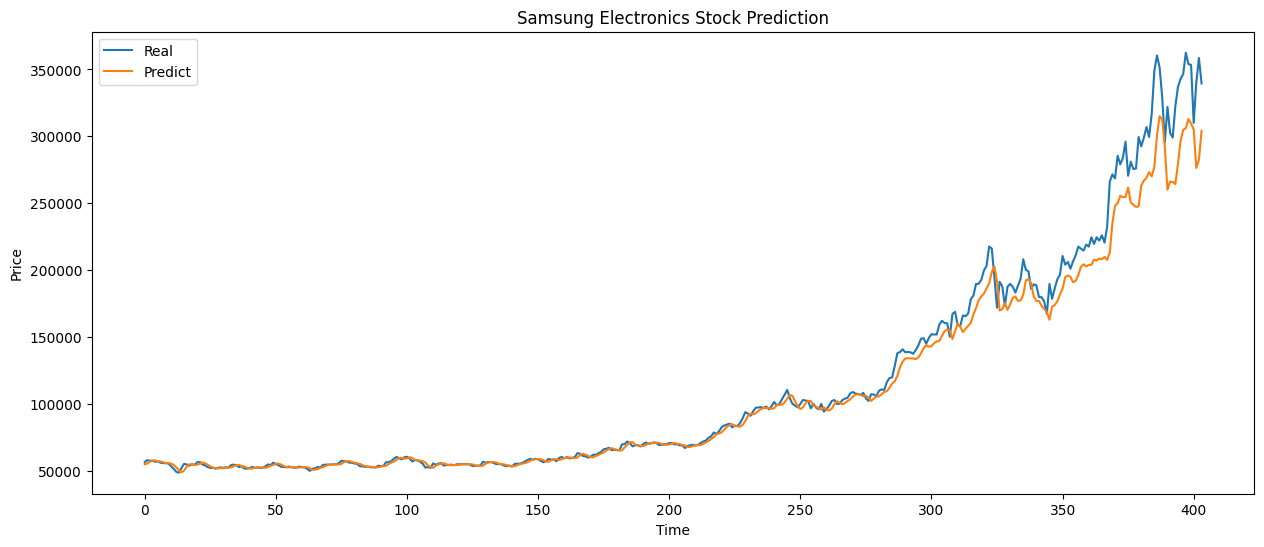

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

예상 내일 종가
302771.8


In [ ]:
# ==========================================
# 삼성전자 주가 예측 (LSTM)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------
# 1. 삼성전자 주가 다운로드
# ------------------------------------------

df = yf.download(
    "005930.KS",
    start="2018-01-01",
    end="2026-06-29",
    auto_adjust=True
)

print(df.head())

# ------------------------------------------
# 2. 종가만 사용
# ------------------------------------------

close = df[['Close']]

# ------------------------------------------
# 3. 정규화
# ------------------------------------------

# 최소값 = 100
# 최대값 = 190
# 공식은
#   190−100
# 현재값−100
	

scaler = MinMaxScaler()
scaled = scaler.fit_transform(close)

# ------------------------------------------
# 4. 시계열 데이터 생성
# 60일 -> 다음날
# ------------------------------------------

window_size = 60

X = []
Y = []

for i in range(window_size, len(scaled)):    
    X.append(scaled[i - window_size:i])
    Y.append(scaled[i])
    #print(scaled[i-window_size:i], scaled[i])
    print(window_size,i)


X = np.array(X)
Y = np.array(Y)

print("X :", X.shape)
print("Y :", Y.shape)

# ------------------------------------------
# 5. Train / Test
# ------------------------------------------

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

Y_train = Y[:train_size]
Y_test = Y[train_size:]

print(X_train.shape)
print(X_test.shape)

# ------------------------------------------
# 6. 모델 생성
# ------------------------------------------


model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64,return_sequences=True),
    LSTM(32),
    Dense(16,activation="relu"),
    Dense(1)
])

# model = Sequential([
#     Input(shape=(window_size, 1)),
#     LSTM(64),
#     Dense(16,activation="relu"),
#     Dense(1)
# ])

model.compile(
    optimizer="adam",
    loss="mse"
) 


model.summary()

# ------------------------------------------
# 7. 컴파일
# ------------------------------------------

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"] # 평균 절대 오차
)

# ------------------------------------------
# 8. EarlyStopping
# ------------------------------------------

es = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# ------------------------------------------
# 9. 학습
# ------------------------------------------

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es]
)

# ------------------------------------------
# 10. 예측
# ------------------------------------------

pred = model.predict(X_test)

# ------------------------------------------
# 11. 원래 가격으로 복원
# ------------------------------------------

pred_price = scaler.inverse_transform(pred)
real_price = scaler.inverse_transform(Y_test)

# ------------------------------------------
# 12. 그래프
# ------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(real_price, label="Real")
plt.plot(pred_price, label="Predict")

plt.title("Samsung Electronics Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()

# ------------------------------------------
# 13. 마지막 60일로 내일 예측
# ------------------------------------------

last60 = scaled[-60:]
last60 = last60.reshape(1,60,1)
tomorrow = model.predict(last60)
tomorrow_price = scaler.inverse_transform(tomorrow)

print()
print("="*40)
print("예상 내일 종가")
print(tomorrow_price[0][0])
print("="*40)